# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [1]:
# Restart the Kernel after you execute this command.

!python -m pip install -r requirements.txt

**Important: Restart the Kernel at this moment**

## Imports

In [2]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [4]:
# Define transforms
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Create training set and define training dataloader
training_data = torchvision.datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root="data", train=False, download=True, transform=transform)

# Create test set and define test dataloader
train_loader = torch.utils.data.DataLoader(training_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32)

## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

**DOUBLE CLICK THIS CELL TO MODIFY**

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [5]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

8


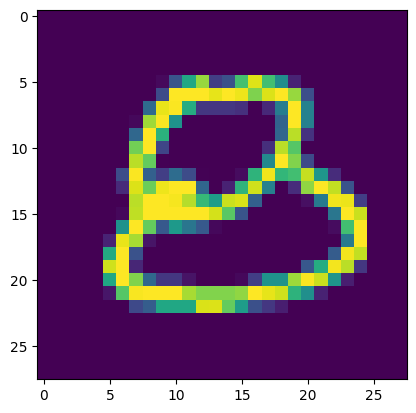

4


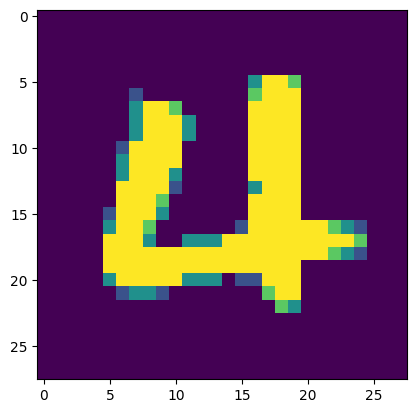

4


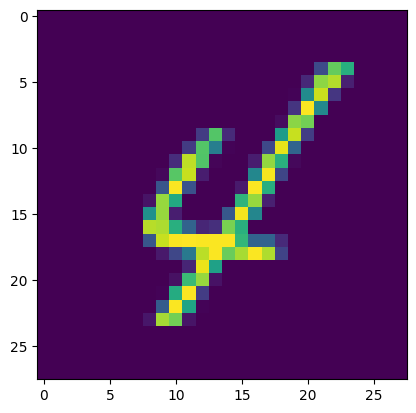

2


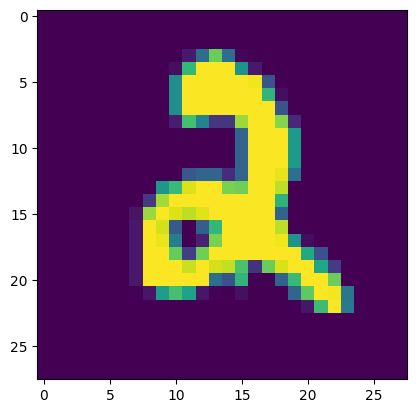

0


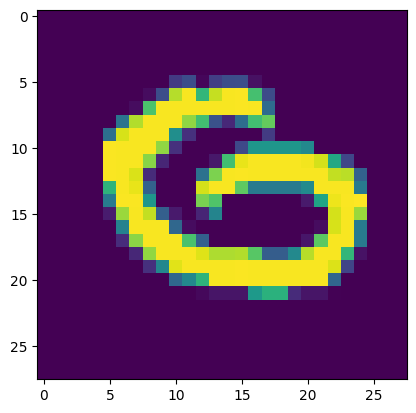

In [6]:
# Explore data
show5(train_loader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [8]:
## Define the neural network — CNN inspired by LeNet-5 (LeCun et al., 1998)
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        # Two convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)   # 28x28 -> 26x26
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)  # 26x26 -> 24x24
        self.pool = nn.MaxPool2d(2)                               # 24x24 -> 12x12
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        # Flatten 64*12*12 = 9216 -> fully connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [9]:
model = MNISTNet().to(device)

# CrossEntropyLoss is the standard choice for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer with default lr=0.001
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [10]:
epochs = 50  # Upper bound — early stopping will likely kick in sooner
patience = 5  # Stop after 5 epochs with no improvement
train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_state = None

for epoch in range(epochs):
    # --- Training ---
    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (batch_idx + 1) % 250 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {running_loss / (batch_idx + 1):.4f}")
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_acc = 100.0 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} — Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # --- Early Stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict().copy()
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1} — no improvement for {patience} epochs.")
            break

# Restore best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
print(f"Training finished. Best Val Loss: {best_val_loss:.4f}")

Epoch 1/50, Batch 250/1875, Loss: 0.5608
Epoch 1/50, Batch 500/1875, Loss: 0.3886
Epoch 1/50, Batch 750/1875, Loss: 0.3133
Epoch 1/50, Batch 1000/1875, Loss: 0.2705
Epoch 1/50, Batch 1250/1875, Loss: 0.2432
Epoch 1/50, Batch 1500/1875, Loss: 0.2227
Epoch 1/50, Batch 1750/1875, Loss: 0.2066
Epoch 1/50 — Train Loss: 0.2003, Val Loss: 0.0549, Val Acc: 98.07%
Epoch 2/50, Batch 250/1875, Loss: 0.1002
Epoch 2/50, Batch 500/1875, Loss: 0.0988
Epoch 2/50, Batch 750/1875, Loss: 0.0967
Epoch 2/50, Batch 1000/1875, Loss: 0.0944
Epoch 2/50, Batch 1250/1875, Loss: 0.0947
Epoch 2/50, Batch 1500/1875, Loss: 0.0939
Epoch 2/50, Batch 1750/1875, Loss: 0.0919
Epoch 2/50 — Train Loss: 0.0915, Val Loss: 0.0367, Val Acc: 98.92%
Epoch 3/50, Batch 250/1875, Loss: 0.0699
Epoch 3/50, Batch 500/1875, Loss: 0.0676
Epoch 3/50, Batch 750/1875, Loss: 0.0694
Epoch 3/50, Batch 1000/1875, Loss: 0.0718
Epoch 3/50, Batch 1250/1875, Loss: 0.0722
Epoch 3/50, Batch 1500/1875, Loss: 0.0726
Epoch 3/50, Batch 1750/1875, Loss: 

Plot the training loss (and validation loss/accuracy, if recorded).

In [ ]:
## YOUR CODE HERE ##

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [ ]:
## YOUR CODE HERE ##

## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [ ]:
## YOUR CODE HERE ##

## Saving your model
Using `torch.save`, save your model for future loading.

In [ ]:
## YOUR CODE HERE ##